# EEG Blink Signals

|Previous Notebook|Current Notebook|Next Notebook|
|:-:|:-:|:-:|
|[2.vr_blink_signals.ipynb](./2.vr_blink_signals.ipynb)|<i>3.eeg_blink_signals.ipynb</i>|[4.offset_calculation.ipynb](./4.offset_calculation.ipynb)|

In the previous notebook [2.vr_blink_signals.ipynb](./2.vr_blink_signals.ipynb), we attempted to derive blinks from VR data. That notebook generated a process to normalize signal data during the calibration phase, then use a peak/valley detection system. The functions relevant to that process are currently accessible in `src/components/blink_handling.py`. 

In THIS notebook, we will attempt to understand HOW blinks are recognized in the **Muse S** system and determine a way to align the data. The inspiration for this is that we've detected some unique signal patterns in the **TP9** and **TP10** channels of the Muse S. So let's actually explore what's going on here.

## Before We Begin: What Does the Literature Say?

According to [this paper (1985)](https://doi.org/10.1152/jn.1985.54.1.11), eye movements result in a downward, nasalward movement of the eyes during a blink gesture. These movements have shorter durations than the eyelid movement, and the movement of the eyes differ from that of the eyelids. Prolonged eye closure results in eye movements that drift upward or downward involuntarily, with a variable horizontal component. It is likely that transient eye movements are likely due to active muscle contractions rather than passive mechanisms of the eyelid. 

There is a mention of ["Bell's Phenomenon"](https://en.wikipedia.org/wiki/Bell%27s_phenomenon), which describes eye movements when an attempt to close the eyes are made. The previous paper mentions that Bell's Phenomenon has not been observed during short blinks. But what is Bell's Phenomenon? Bell's Phenomenon is defined as the following (simplified on Wikipedia, originally sourced by [this paper (2001)](https://pmc.ncbi.nlm.nih.gov/articles/PMC1121451/)):

> "[An] upward and outward movement of the eye, when an attempt is made to close the eyes. The upward movement of the eye is present in the majority of the population, and is a defensive mechanism."

[This video (2022)](https://www.youtube.com/watch?v=wxmBSyWD4mU&t=82s) elaborates that Bell's Phenomenon is a **defensive reflex** that occurs during **forced** eye closure (i.e. when something is about to hit your face and you force-close your eyes to protect them). It is not immediately clear from this video if Bell's Phenomenon is something that occurs **normally** during blinks.

[This report (2022)](https://isip.piconepress.com/conferences/ieee_spmb/2022/papers/l01_03.pdf) directly from the company that made Muse (supposedly) describes their algorithm for detecting blinks using single electrodes. They explain the same thing we've observed - that there's an aggressive valley accompanied by a smaller peak that's associated with a blink gesture. They use an algorithm that's actually kind of effective and makes very little assumptions about the signal behavior prior. They define the blink behavior as such:

> Eye-blinks are noticeable in EEG signal recordings, as seen in Figure 1, and can be described with respect to
the measured baseline voltage. The eye-blink starts with a steep drop in the measured voltage, representing the
closing of the eyelid. It is then followed by a steep rise that crosses the baseline and reaches higher voltages,
representing the opening of the eyelid. Finally, it is followed by a return to the measured baseline.

### Inferences to our work

I think at this point, it's safe to bet about the following:

- In the EEG signal, when the eye is closed, this corresponds to the largest detected valley. The signal will always return to the baseline (which can be measured based on the mean of the signal).
- If we want any blink alignment with other systems, then we need to time it in comparison to this minimum valley.

## Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import importlib
from scipy.stats import zscore

from components import eeg_handling
importlib.reload(eeg_handling)

_DATA_DIR = 'data2'
_EXAMPLE_PARTICIPANT = 'P4_Muse2'

## Premise: Looking at EEG Data

Honestly, most participants' EEG data is pretty clean for our analysis. Before, in [2.vr_blink_signals.ipynb](./2.vr_blink_signals.ipynb), we used `P4_Muse2` as our test case. Let's do the same and look at `P4_Muse2`'s EEG data - specifically, the `TP9` data (we could also look at the `TP10` channel, but it's mostly the same).

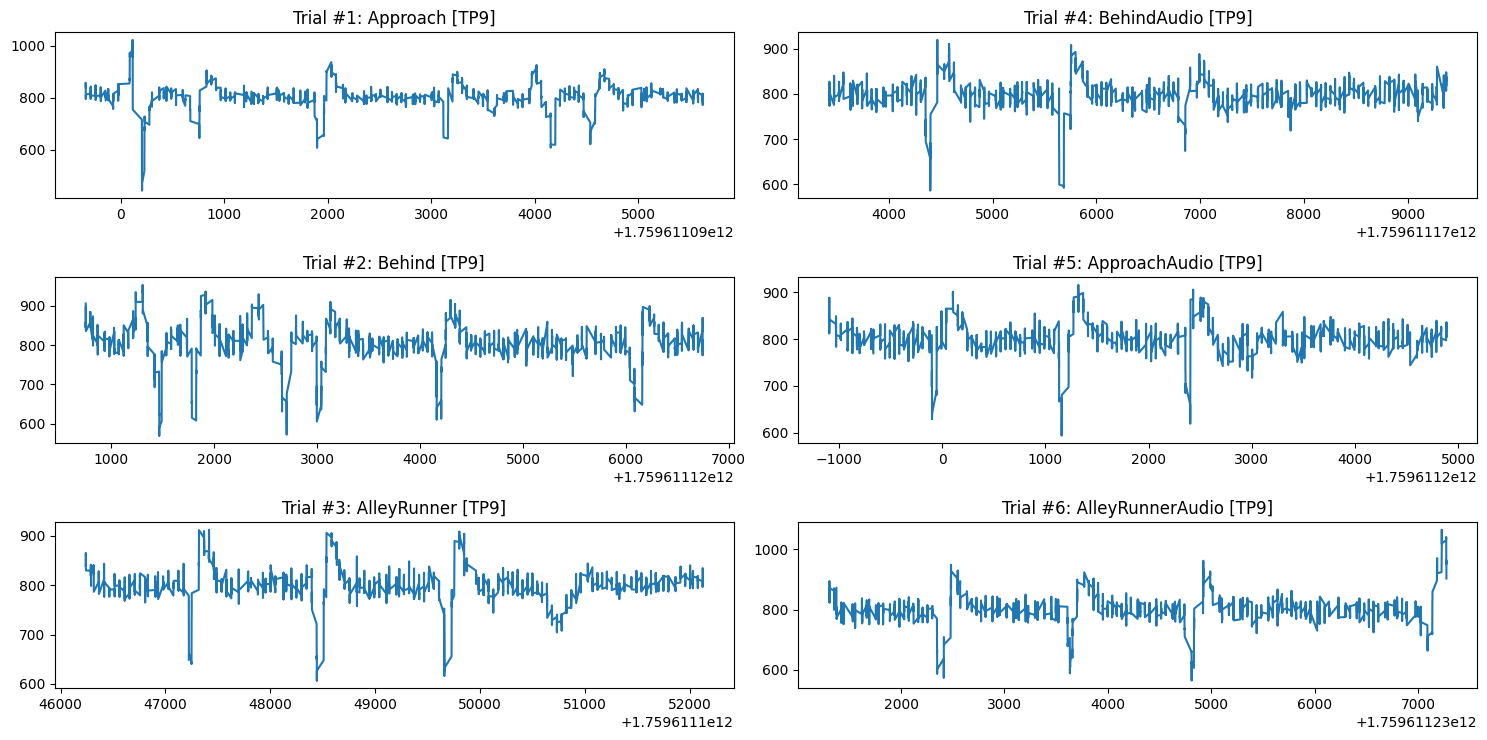

In [2]:
# Centralize to the particiapnt's directory
pdir = os.path.join('.', _DATA_DIR, _EXAMPLE_PARTICIPANT)

# Read the trial data
trials = pd.read_csv(os.path.join(pdir, "trials.csv"))

# Plot the figure. Since we're looking at all 6 trials, let's make a 3-row, 2-col figure
fig, axes = plt.subplots(3,2,figsize=(15,7.5))

# Iterate through trials
for _, row in trials.iterrows():

    # Read the eye data for each trial
    trial_id = row['trial_id']
    trial_name = row['trial_name']

    # Get the row and column indices in our figure
    row_index = math.floor((trial_id-1) % 3)
    col_index = math.floor((trial_id-1)/ 3)

    # Get the trial directory
    tdir = os.path.join(pdir, f"{trial_id}", 'calibration')

    # Read the necessary datasets'
    eeg_raw = pd.read_csv(os.path.join(tdir, 'eeg_raw.csv'))

    # From `eeg_raw`, get the start and end milliseconds. Then filter the rows of `eeg_raw`
    start_ms = eeg_raw['unix_ms'].iloc[0] + 5000
    end_ms = eeg_raw['unix_ms'].iloc[-1] - 500
    eeg = eeg_raw[eeg_raw['unix_ms'].between(start_ms, end_ms)]

    # Get x and y
    x = eeg['unix_ms'].to_list()
    y = eeg['TP9'].to_list()

    # Plot eeg data
    ax = axes[row_index][col_index]
    ax.plot(x, y)
    ax.set_title(f"Trial #{trial_id}: {trial_name} [TP9]")

# Show
plt.tight_layout()
plt.show()


Just looking at this data gives me the shivers. We can clearly identify the moments when the blink LIKELY happens, but the data is so noisy! I don't like doing this, but it is actually somewhat optimal to smooth the data before we do anything else.

## Exploration: Blink Samples

I went to record my own blink samples using our **Muse S** device - just to see the behavior of the EEG during specific blink characteristics. This data resides within `src/blink_samples/` and comprises of 2 blink samples.

In [3]:
_BLINK_SAMPLES_DIR = os.path.join('.', 'blink_samples/')
_BLINK_SAMPLES = [
    os.path.join(_BLINK_SAMPLES_DIR, 'sample_1.csv'),
    os.path.join(_BLINK_SAMPLES_DIR, 'sample_2.csv')
]

# load the raw samples as dataframes
raw_samples = [{'df':eeg_handling.separate(eeg_handling.read(s)[0])[0], 'name':os.path.basename(s)} for s in _BLINK_SAMPLES]

d:\Projects\eeg_blink_calibration\src\components\eeg_handling.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_df.rename(columns=raw_colnames, inplace=True)
d:\Projects\eeg_blink_calibration\src\components\eeg_handling.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_df.rename(columns=raw_colnames, inplace=True)


Now, let's attempt to render these in a 2x2 figure for easy plotting:

And finally, render the plots

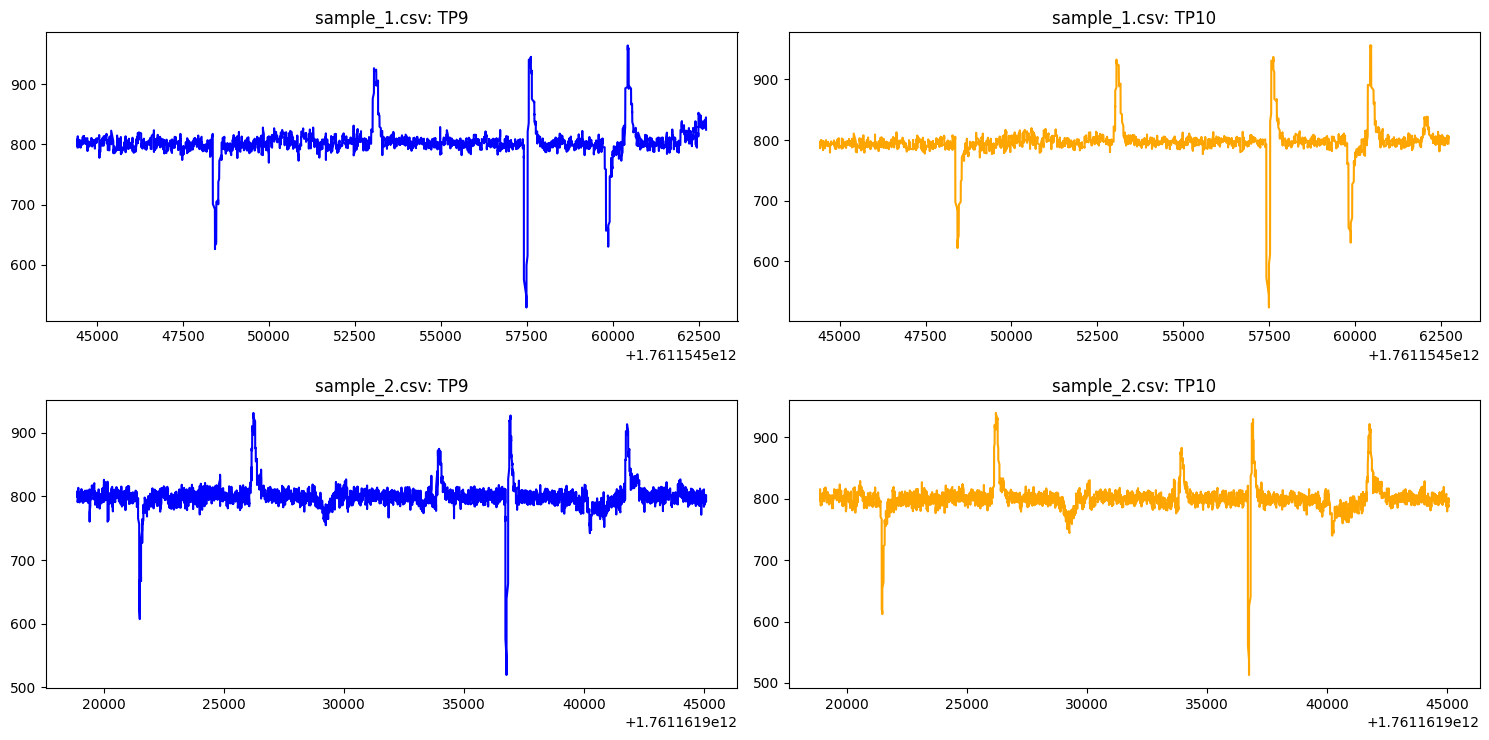

In [4]:
# Plot a figure to showcase the TP9s of these two samples
fig, axes = plt.subplots(2,2,figsize=(15,7.5))

# Iterate through our two samples
for i in range(len(raw_samples)):
    sample = raw_samples[i]

    df = sample['df']
    x = df['unix_ms'].to_list()
    tp9 = df['TP9'].to_list()
    tp10 = df['TP10'].to_list()

    axes[i][0].plot(x, tp9, c='blue')
    axes[i][0].set_title(f"{sample['name']}: TP9")
    axes[i][1].plot(x, tp10, c='orange')
    axes[i][1].set_title(f"{sample['name']}: TP10")

# Render the plot
plt.tight_layout()
plt.show()

### `sample_1.csv` (Top Row)

1. The first major VALLEY corresponds to the eye in a closing motion, and keeping them closed. It looks like, upon the blink being completed, the signal returns to its original median signal value even when the eye remains closed.
2. The first major PEAK corresponds to the eye opening after keeping it closed.
3. The first major valley => peak corresponds to a normal blink. It appears that the speed (or strength?) of the blink corresponds to the strength of the valley and only to the peak a little bit.
4. The second major valley => peak corresponds to a slower blink.
5. When the eyes are closed, upon closing, there's a little bit of a delay where the signal power in both TP9 and TP10 remain slightly _below_ the midline, but this only lasts for a few milliseconds. This is evident in the first major valley as well as blink.

### `sample_2.csv` (Bottom Row)
This represents a sample where half-closed eyes were also present. The order of the events are:

1. Close eyes, keep closed
2. Open eyes from closed
3. Close eyes halfway, keep halfway closed
4. Open eyes from closed
5. Normal blink
6. Slow blink

From the resulting graphs, we can determine:

- The eyes closed and the eyes half-closed produce similar patterns, but the strength of the valley and peaks are smaller for the half-closed condition.
- The data looks wonky with the slow blink, so let's ignore that.

### Commonalities
Across both samples, there are some notable things to consider, from this pattern:

- **The action of closing the eye produces a valley**.
- **The action of opening the eye produces a peak**.
- It can be _intuitied_ that for a blink detection system, we can safely identify the moment on the blink as when:
    1. the valley passes the midline towards the peak, and/or,
    2. The short moment when the signal power is slighly below the midline.

## Smoothed Data?

Let's smooth out the data and see if we get improved results. To achieve the smoothing, I'm using the popular [Savitzky-Golay Filter](https://en.wikipedia.org/wiki/Savitzky%E2%80%93Golay_filter), implemented via [scipy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.savgol_filter.html). The filter is described further via [this video](https://www.youtube.com/watch?v=cY-OBfCnOxU). Let's create an **interactive** visualization that let's us adjust the filter params.

In [5]:
from scipy.signal import savgol_filter
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown

# since we already provided `generate_figure()` above, we just need to make sure that we create a helper function to connect `interact()` with `generate_figure()`
def update_plot(wl=100, poly=3, mode='nearest'):

    # Generate the savgol filter itself
    savgol = lambda d: savgol_filter(d, window_length=wl, polyorder=poly, mode=mode)

    # Plot a figure to showcase the TP9s of these two samples
    fig, axes = plt.subplots(2,2,figsize=(15,7.5))

    # Iterate through our two samples
    for i in range(len(raw_samples)):
        sample = raw_samples[i]

        df = sample['df']
        x = df['unix_ms'].to_list()
        tp9 = df['TP9'].to_list()
        tp10 = df['TP10'].to_list()

        tp9_z = zscore(tp9)
        tp10_z = zscore(tp10)

        axes[i][0].plot(x, tp9_z, c='blue', alpha=0.25)
        axes[i][0].set_title(f"{sample['name']}: TP9")
        axes[i][1].plot(x, tp10_z, c='orange', alpha=0.25)
        axes[i][1].set_title(f"{sample['name']}: TP10")

        axes[i][0].plot(x, savgol(tp9_z), c='blue')
        axes[i][1].plot(x, savgol(tp10_z), c='orange')

    # Render the plot
    plt.tight_layout()
    plt.show()


# Inputs
interact(
    update_plot,
    wl = FloatSlider(value=50, min=10, max=200, step=0.1, description='Window Length'),
    poly = IntSlider(value=3, min=1, max=5, step=1, description='Poly Order'),
    mode = Dropdown(options=['mirror', 'constant', 'nearest', 'wrap', 'interp'], value='nearest', description='Mode')
)

interactive(children=(FloatSlider(value=50.0, description='Window Length', max=200.0, min=10.0), IntSlider(val…

<function __main__.update_plot(wl=100, poly=3, mode='nearest')>

These results are, for the most part, pleasing. It appears that a window length of `75` and a polyorder of `3` with the `nearest` mode is optimal for removing most noise while still maintaining its overall structure and the sharpness of the peaks. Furthermore, when looking at the 2nd row of figures (corresponding to `sample_2.csv`, which has half-blinks), we find some interesting trends:

1. The eyes closed and the eyes half-closed produce similar patterns, but the strength of the valley and peaks are smaller for the half-closed condition.
2. The data looks wonky with the slow blink, so let's ignore that.

This gives us some idea of what's happening: when the blink occurs, the strength of the signal noise generated is proportional to the amount of movement. Half-blinks will disrupt the EEG no more than halfway than a full eye-closed motion, for example. The inherent pattern still holds, nonetheless.

## Samples & Peak-Finding

Let's import the helper code we generated from the previous notebook, now available in `src/components/blink_handling.py`, and see if we can get it to run with our sample data.

In [6]:
from components import blink_handling
importlib.reload(blink_handling)

<module 'components.blink_handling' from 'd:\\Projects\\eeg_blink_calibration\\src\\components\\blink_handling.py'>

This component script contains a helper function called `calculate_peaks()`. It requires two params: `_X`, and `_Y`. There are additional, optional parameters but we won't touch those. The function returns 3 items: 1) a combined, sorted array of all peaks and valleys in the data, 2) only the peaks, and 3) only the valleys.

There's another function called `detect_vr_blinks()` which actually calls this function, but it does some extra steps to read the participant's data and process it in a meaningful way. We'll have to pull from that to convert the returned data into Pandas DataFrames, then identify only the first peaks/valleys, and render those.

In [7]:
def get_blinks_and_z(x, y):

    # Run the function
    blinks, _, _, z = blink_handling.calculate_peaks(x, y)

    # Convert the blinks into a DataFrame
    if blinks is not None:  blinks_df = pd.DataFrame(blinks)
    else:                   blinks_df = None

    # return the dataframe
    return blinks_df, z

# Iterate through our `raw_samples`. AKA iterate first through `sample_1.csv`, then `sample_2.csv`
for samples in raw_samples:
    x = samples['df']['unix_ms'].to_list()
    tp9 = samples['df']['TP9'].to_list()
    tp10 = samples['df']['TP10'].to_list()

    # for each, detect blink samples
    tp9_blinks, tp9_z = get_blinks_and_z(x, tp9)
    tp10_blinks, tp10_z = get_blinks_and_z(x, tp10)

    # let's visualize them
    display(tp9_blinks, tp10_blinks)

,type,x,y
0,valley,1761154545068,-0.812935
1,peak,1761154545411,0.682549
2,valley,1761154545695,-0.636196
3,peak,1761154546653,0.709738
4,valley,1761154546955,-0.595410
5,peak,1761154547424,0.505810
6,valley,1761154547477,-0.962484
7,valley,1761154548286,-0.785745
8,peak,1761154548364,0.505810
9,valley,1761154548429,-5.516915


,type,x,y
0,valley,1761154545723,-0.599514
1,peak,1761154546655,0.558248
2,valley,1761154547478,-0.641361
3,valley,1761154548429,-5.509542
4,valley,1761154548746,-0.808748
5,peak,1761154548973,0.530352
6,valley,1761154549081,-0.850595
7,valley,1761154549432,-0.683208
8,valley,1761154549784,-0.627412
9,peak,1761154549824,0.697737


,type,x,y
0,valley,1761161919390,-1.692270
1,peak,1761161919587,0.883338
2,valley,1761161919707,-0.730708
3,valley,1761161919809,-0.816561
4,peak,1761161919987,1.106557
...,...,...,...
181,valley,1761161944651,-0.644854
182,valley,1761161944799,-0.610513
183,peak,1761161944825,0.522754
184,valley,1761161944876,-1.228660


,type,x,y
0,peak,1761161919113,0.755424
1,valley,1761161919388,-0.641006
2,valley,1761161919420,-0.641006
3,peak,1761161919709,0.954916
4,valley,1761161919860,-0.508013
...,...,...,...
137,peak,1761161943280,0.589182
138,peak,1761161944002,0.805297
139,peak,1761161944078,1.171031
140,valley,1761161944327,-0.790623


In [8]:
# since we already provided `generate_figure()` above, we just need to make sure that we create a helper function to connect `interact()` with `generate_figure()`
def update_plot(wl=100, poly=3, mode='nearest'):

    # Generate the savgol filter itself
    savgol = lambda d: savgol_filter(d, window_length=wl, polyorder=poly, mode=mode)

    # Plot a figure to showcase the TP9s of these two samples
    fig, axes = plt.subplots(2,2,figsize=(15,7.5))

    # Iterate through our two samples
    for i in range(len(raw_samples)):
        sample = raw_samples[i]

        df = sample['df']
        x = df['unix_ms'].to_list()
        tp9 = df['TP9'].to_list()
        tp10 = df['TP10'].to_list()

        tp9s = savgol(tp9)
        tp10s = savgol(tp10)

        tp9_blinks, tp9_z = get_blinks_and_z(x, tp9s)
        tp10_blinks, tp10_z = get_blinks_and_z(x, tp10s)

        axes[i][0].plot(x, tp9_z, c='blue', alpha=0.25)
        axes[i][0].set_title(f"{sample['name']}: TP9 Normalized")
        axes[i][1].plot(x, tp10_z, c='orange', alpha=0.25)
        axes[i][1].set_title(f"{sample['name']}: TP10 Normalized")

        for _, row in tp9_blinks.iterrows():
            axes[i][0].axvline(x=row['x'], c='red')
        for _, row in tp10_blinks.iterrows():
            axes[i][1].axvline(x=row['x'], c='steelblue')

    # Render the plot
    plt.tight_layout()
    plt.show()

# Inputs
interact(
    update_plot,
    wl = FloatSlider(value=50, min=10, max=200, step=0.1, description='Window Length'),
    poly = IntSlider(value=3, min=1, max=5, step=1, description='Poly Order'),
    mode = Dropdown(options=['mirror', 'constant', 'nearest', 'wrap', 'interp'], value='nearest', description='Mode')
)

interactive(children=(FloatSlider(value=50.0, description='Window Length', max=200.0, min=10.0), IntSlider(val…

<function __main__.update_plot(wl=100, poly=3, mode='nearest')>

This one's definitely going to be noisy, because `calculate_blinks()` wasn't meant to handle raw data in of itself. However, I am pleased that, at the very least, there are lines that do match up with the clearly-identifiable peaks and valleys that correspond to the EEG data.

## Final Output: Formalizing Everything

We've done a lot with this notebook. Namely, we determined that the steps to follow are:

1. Use `savgol_filter()` with `window_length=75`, `polyorder=3`, and `mode='nearest'` to smoothen the original TP9 and TP10 data
2. Isolate to the four overlaps of the participant
3. Within Used `blink_handling.calculate_peaks()` to measure the valleys of the z-scores of the smoothed EEG data

The new function, `detect_eeg_blinks()`, provides a similar functionality to `blink_handling.detect_vr_blinks()` where all that's needed to be provided is the participant's name and data directory. The `detect_eeg_blinks()` returns 2 separate blink data: one for the TP9, and another for the TP10. The first 2 entries are the first blinks for each overlap, while the latter two are the full blink data for TP9 and TP10

In [9]:
def detect_eeg_blinks(_DATA_DIR:str, _PARTICIPANT:str,
                      window_length=75,
                      polyorder=3,
                      mode='nearest',
                      peak_height=0.5, 
                      peak_prominence=1, 
                      peak_width=0, 
                      valley_height=0.5, 
                      valley_prominence=1, 
                      valley_width=0,
                      smooth_data:bool=True):
    
    # Define a global directory for this participant
    pdir = f"./{_DATA_DIR}/{_PARTICIPANT}/"

    # Get trials of this participant
    trials = pd.read_csv(os.path.join(pdir, "trials.csv"))
    
    # list of outputs
    all_results = {'TP9':[], 'TP10':[]}

    # iterate through trials
    for _, row in trials.iterrows():
        # Read the eye data for each trial
        trial_id = row['trial_id']
        tdir = os.path.join(pdir, f"{trial_id}", "calibration")

        # Read the necessary datasets
        eeg_raw = pd.read_csv(os.path.join(tdir, 'eeg_raw.csv'))
        brdf = pd.read_csv(os.path.join(tdir, "blink_ranges.csv"))

        # From `eeg_raw`, get the start and end milliseconds. Then filter the rows of `eeg_raw`
        start_ms = eeg_raw['unix_ms'].iloc[0] + 5000
        end_ms = eeg_raw['unix_ms'].iloc[-1] - 500
        eeg = eeg_raw[eeg_raw['unix_ms'].between(start_ms, end_ms)]
        
        # Iterate through each blink range
        for _, row in brdf.iterrows():

            # Get necessary timestamps
            overlap_counter = row['overlap_counter']
            range_start_ms = row['start_unix_ms']
            range_end_ms = row['end_unix_ms']
            _eeg = eeg[eeg['unix_ms'].between(range_start_ms, range_end_ms)]

            # Get the relevant x and y data
            x = _eeg['unix_ms'].to_list()
            tp9 = _eeg['TP9'].to_list()
            tp10 = _eeg['TP10'].to_list()

            # Smooth the data, if prompted
            if smooth_data:
                tp9 = savgol_filter(tp9, window_length=window_length, polyorder=polyorder, mode=mode)
                tp10 = savgol_filter(tp10, window_length=window_length, polyorder=polyorder, mode=mode)

            # Calculate the blinks
            _, _, tp9_valleys, tp9z = blink_handling.calculate_peaks(
                x, tp9, 
                peak_height=peak_height, 
                peak_prominence=peak_prominence, 
                peak_width=peak_width, 
                valley_height=valley_height, 
                valley_prominence=valley_prominence, 
                valley_width=valley_width )
            _, _, tp10_valleys, tp10z = blink_handling.calculate_peaks(
                x, tp10,
                peak_height=peak_height, 
                peak_prominence=peak_prominence, 
                peak_width=peak_width, 
                valley_height=valley_height, 
                valley_prominence=valley_prominence, 
                valley_width=valley_width )
            
            # Handle cases
            if tp9_valleys is not None: 
                results = [{'trial_id':trial_id, 'overlap_counter':overlap_counter, **c} for c in tp9_valleys]
                all_results['TP9'].extend(results)
            if tp10_valleys is not None: 
                results = [{'trial_id':trial_id, 'overlap_counter':overlap_counter, **c} for c in tp10_valleys]
                all_results['TP10'].extend(results)

    # We'll combine all our results into single dataframes for TP9 and TP10
    tp9_df = pd.DataFrame(all_results['TP9'])
    tp9_df = tp9_df.groupby(['trial_id', 'overlap_counter'], group_keys=False).apply(lambda g: g.sort_values('x'))
    tp10_df = pd.DataFrame(all_results['TP10'])
    tp10_df = tp10_df.groupby(['trial_id', 'overlap_counter'], group_keys=False).apply(lambda g: g.sort_values('x'))

    # We'll extract the first of each trial and overlap
    first_valleys_tp9 = tp9_df.groupby(['trial_id', 'overlap_counter'], as_index=False).first()
    first_valleys_tp10 = tp10_df.groupby(['trial_id', 'overlap_counter'], as_index=False).first()

    # return the dfs
    return first_valleys_tp9, first_valleys_tp10, tp9_df, tp10_df, tp9z, tp10z

### Where Are These Functions Saved?

This function is saved in `src/components/blink_handling.py`. You can easily access it by importing them there.

## Testing Our Helper Functions

In [10]:
importlib.reload(blink_handling)

tp9_first_blinks, tp10_first_blinks, _, _, _, _ = detect_eeg_blinks('./data2', 'P4_Muse2', window_length=50, polyorder=4, smooth_data=True)
display(tp9_first_blinks)
display(tp10_first_blinks)

C:\Users\Ryan Kim\AppData\Local\Temp\ipykernel_23056\615265340.py:84: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tp9_df = tp9_df.groupby(['trial_id', 'overlap_counter'], group_keys=False).apply(lambda g: g.sort_values('x'))
C:\Users\Ryan Kim\AppData\Local\Temp\ipykernel_23056\615265340.py:86: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tp10_df = tp10_df.groupby(['trial_id', 'overlap_counter'], group_ke

,trial_id,overlap_counter,type,x,y
0,1,1.0,valley,1759611090757,-2.505067
1,1,2.0,valley,1759611091896,-2.447335
2,1,3.0,valley,1759611093117,-2.363673
3,1,4.0,valley,1759611094153,-2.096487
4,2,1.0,valley,1759611121782,-2.343857
5,2,3.0,valley,1759611124162,-2.144363
6,2,4.0,valley,1759611126085,-3.264959
7,3,1.0,valley,1759611147224,-2.317707
8,3,2.0,valley,1759611148443,-2.306536
9,3,3.0,valley,1759611149659,-2.266467


,trial_id,overlap_counter,type,x,y
0,1,1.0,valley,1759611090757,-2.274818
1,1,2.0,valley,1759611091896,-2.365417
2,1,3.0,valley,1759611093117,-2.335653
3,1,4.0,valley,1759611094154,-1.853186
4,2,1.0,valley,1759611121782,-2.194694
5,2,2.0,valley,1759611122997,-1.938619
6,2,3.0,valley,1759611124162,-2.080067
7,2,4.0,valley,1759611126085,-3.299484
8,3,1.0,valley,1759611147224,-2.298710
9,3,2.0,valley,1759611148443,-2.386087


Now let's graph the data. Note that: 

1. we'll only be looking at `TP9` data, and
2. we'll be following along the convention that we converted the data into z-score normalized versions of the data.

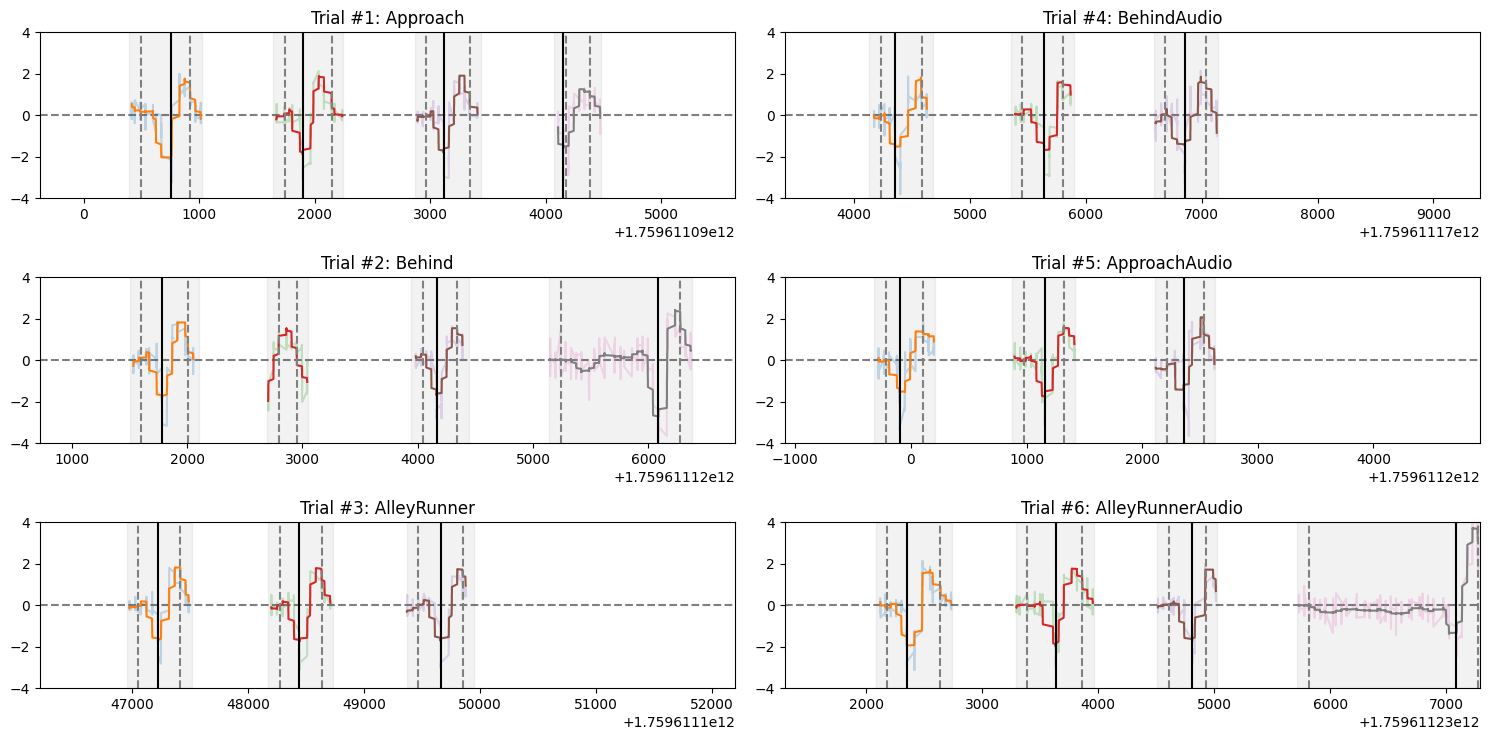

In [11]:
from scipy.stats import zscore

# Plot the figure. Since we're looking at all 6 trials, let's make a 3-row, 2-col figure
fig, axes = plt.subplots(3,2,figsize=(15,7.5))

# Read the trial data
pdir = os.path.join('.', 'data2', _EXAMPLE_PARTICIPANT)
trials = pd.read_csv(os.path.join(pdir, "trials.csv"))

# Iterate through trials
for _, row in trials.iterrows():
    # Derive the trial info
    trial_id = row['trial_id']
    tdir = os.path.join(pdir, f"{trial_id}", 'calibration')

    # Read the necessary datasets
    eeg_raw = pd.read_csv(os.path.join(tdir, 'eeg_raw.csv'))
    brdf = pd.read_csv(os.path.join(tdir, 'blink_ranges.csv'))

    # Restrict the EEG data
    start_ms = eeg_raw['unix_ms'].iloc[0] + 5000
    end_ms = eeg_raw['unix_ms'].iloc[-1] - 500
    eeg = eeg_raw[eeg_raw['unix_ms'].between(start_ms, end_ms)]

    # Get the subplot indices
    row_index = math.floor((trial_id-1) % 3)
    col_index = math.floor((trial_id-1)/ 3)

    # Plot eye data
    ax = axes[row_index][col_index]
    ax.set_title(f"Trial #{trial_id}: {row['trial_name']}")
    ax.set_xlim(start_ms, end_ms)
    ax.set_ylim(-4, 4)
    ax.axhline(y=0, c='black', linestyle='--', alpha=0.5)

    # Plot blink ranges
    for _, row in brdf.iterrows():
        # Get necessary timestamps
        overlap_counter = row['overlap_counter']
        overlap_ms = row['overlap_unix_ms']
        blink_ms = row['blink_unix_ms']
        range_start_ms = row['start_unix_ms']
        range_end_ms = row['end_unix_ms']
        _eeg = eeg[eeg['unix_ms'].between(range_start_ms, range_end_ms)]

        # Get the relevant x and y data
        x = _eeg['unix_ms'].to_list()
        y = _eeg['TP9'].to_list()
        ys = savgol_filter(y, window_length=75, polyorder=3, mode='nearest')
        z_scores = zscore(ys)

        # Plot things
        ax.plot(x, zscore(y), alpha=0.25)
        ax.plot(x, z_scores)
        ax.axvline(x=overlap_ms, c='gray', linestyle='--')
        ax.axvline(x=blink_ms, c='gray', linestyle='--')
        ax.axvspan(xmin=range_start_ms, xmax=range_end_ms, color='gray', alpha=0.1)

        # This time, we pull from `first_blinks`
        estimations = tp9_first_blinks[(tp9_first_blinks['trial_id']==trial_id) & (tp9_first_blinks['overlap_counter']==overlap_counter)]
        for _, estimate in estimations.iterrows():
            # Draw a vertical line to indicate the estimated blink
            ax.axvline(x=estimate['x'], c='black')

plt.tight_layout()
plt.show()

## Saving our Results

Let's do the following: for each participant, we do the following:

1. Save the vr blinks inside of `[TP9 or TP10]_blinks.csv`, inside their respective directories.
2. Save the outputs inside of `./docs/3.eeg_blinks/`. We'll save a figure for each participant.

#### Participant P1

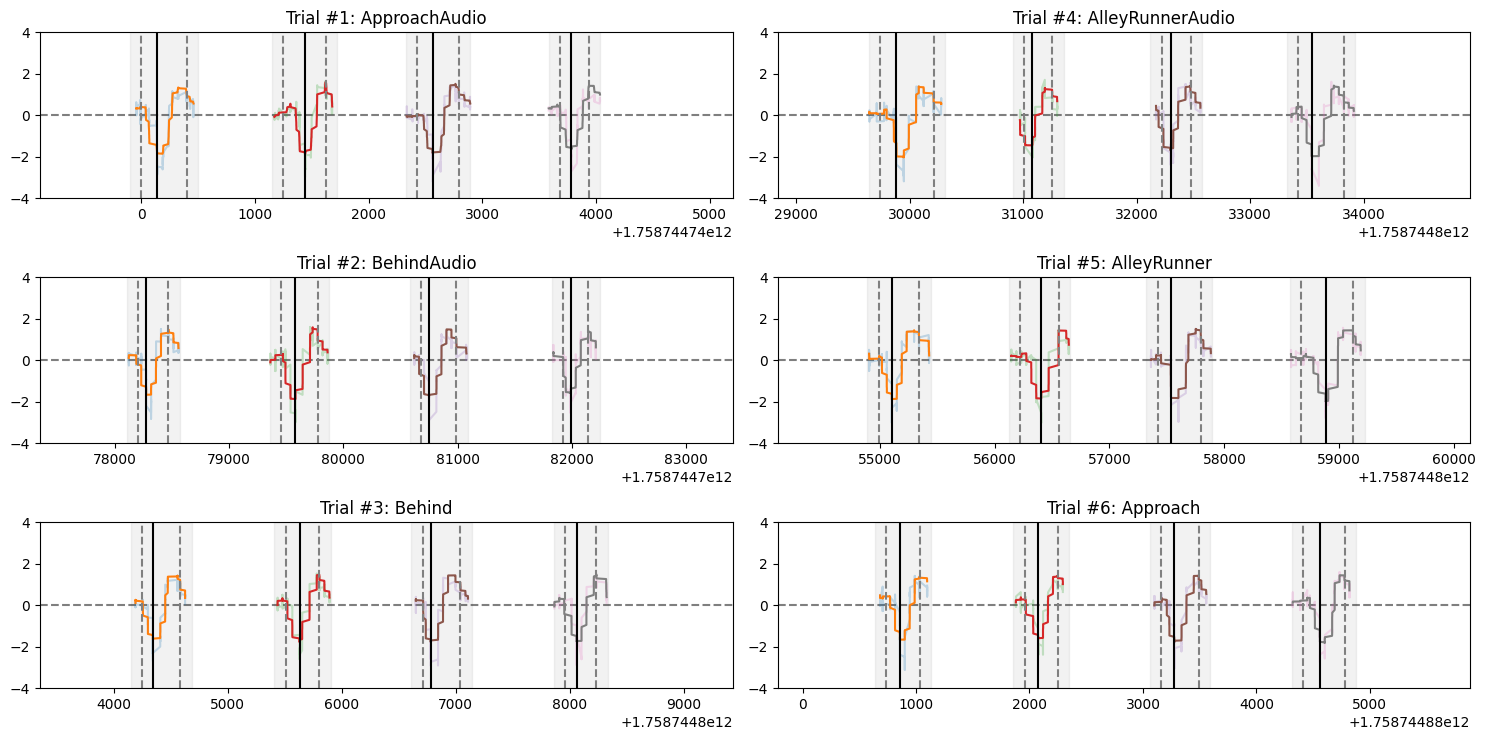

#### Participant PI2

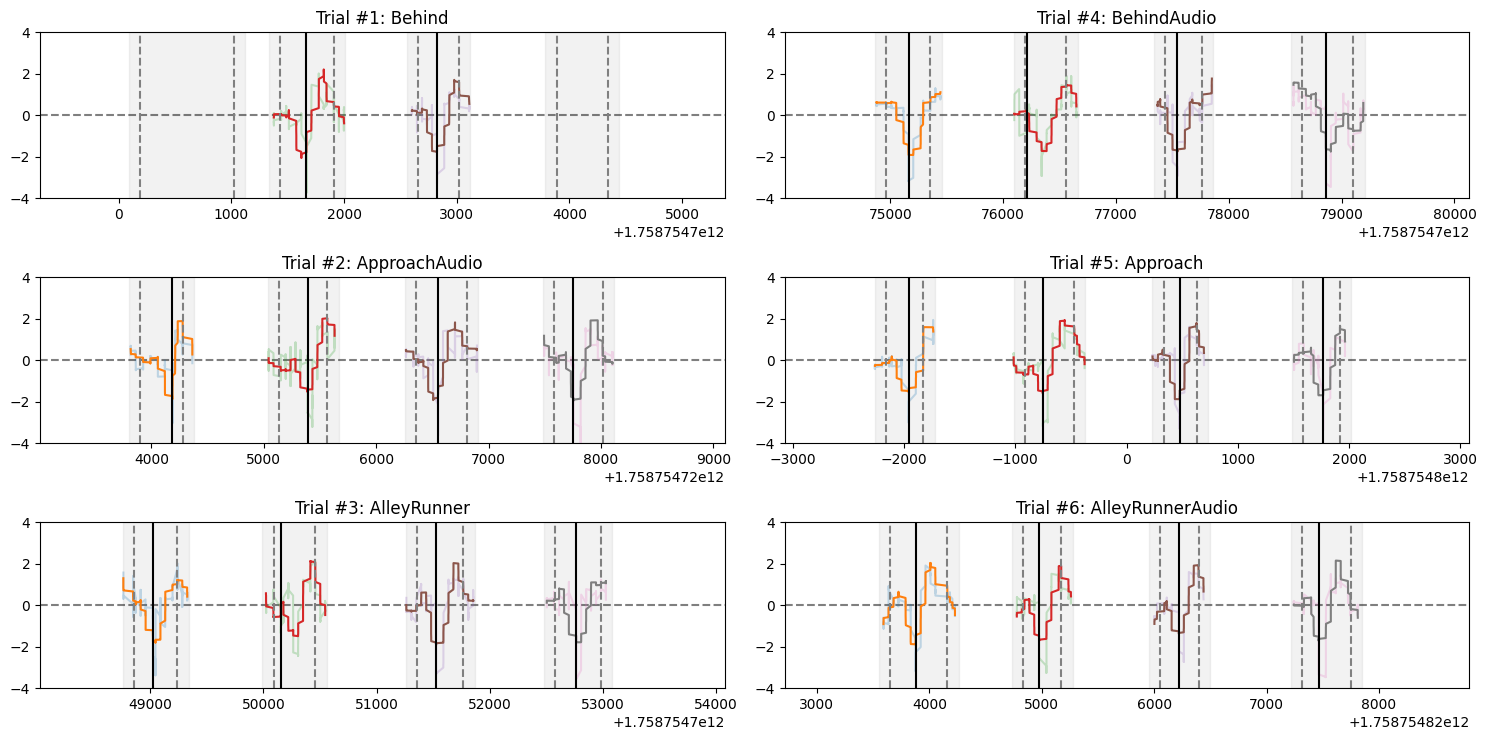

#### Participant P3

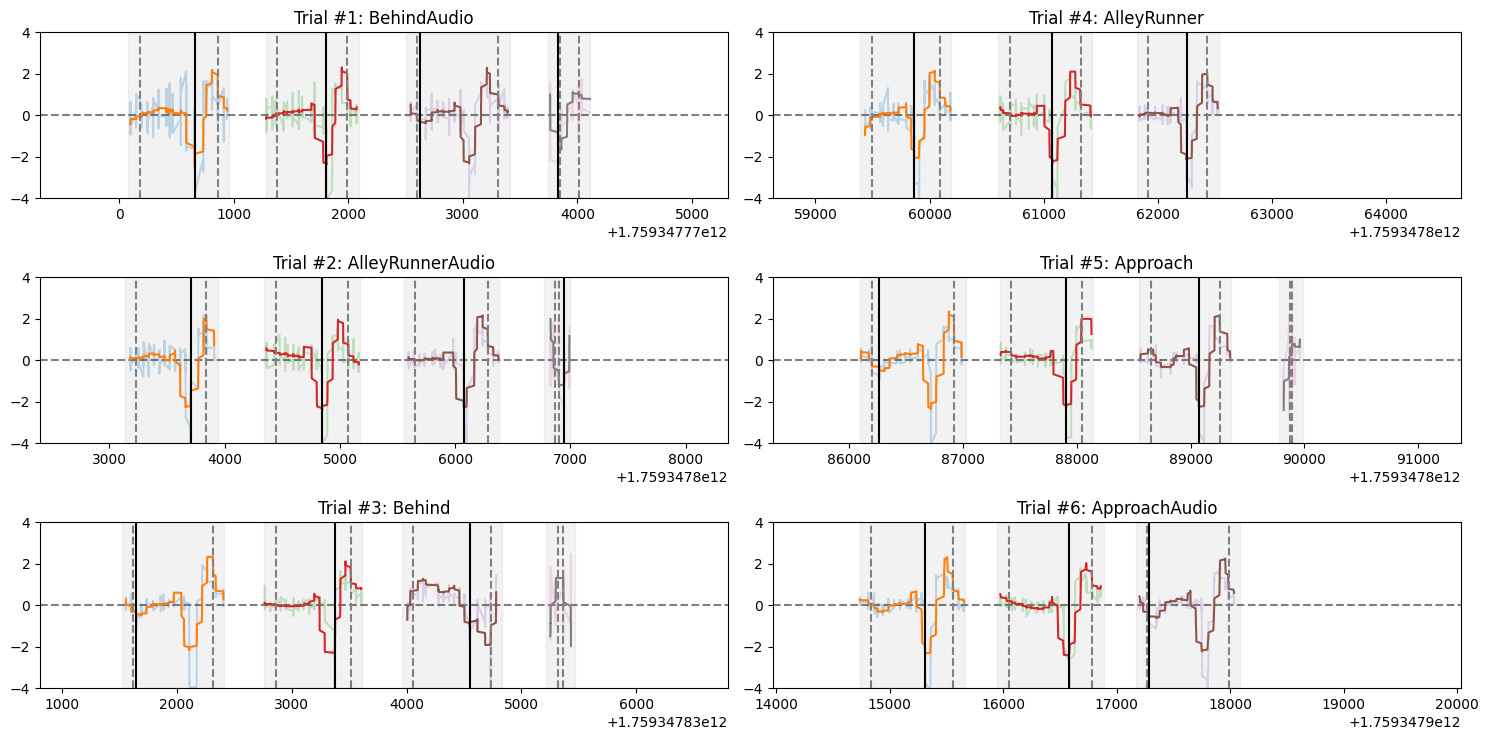

#### Participant P4_Muse2

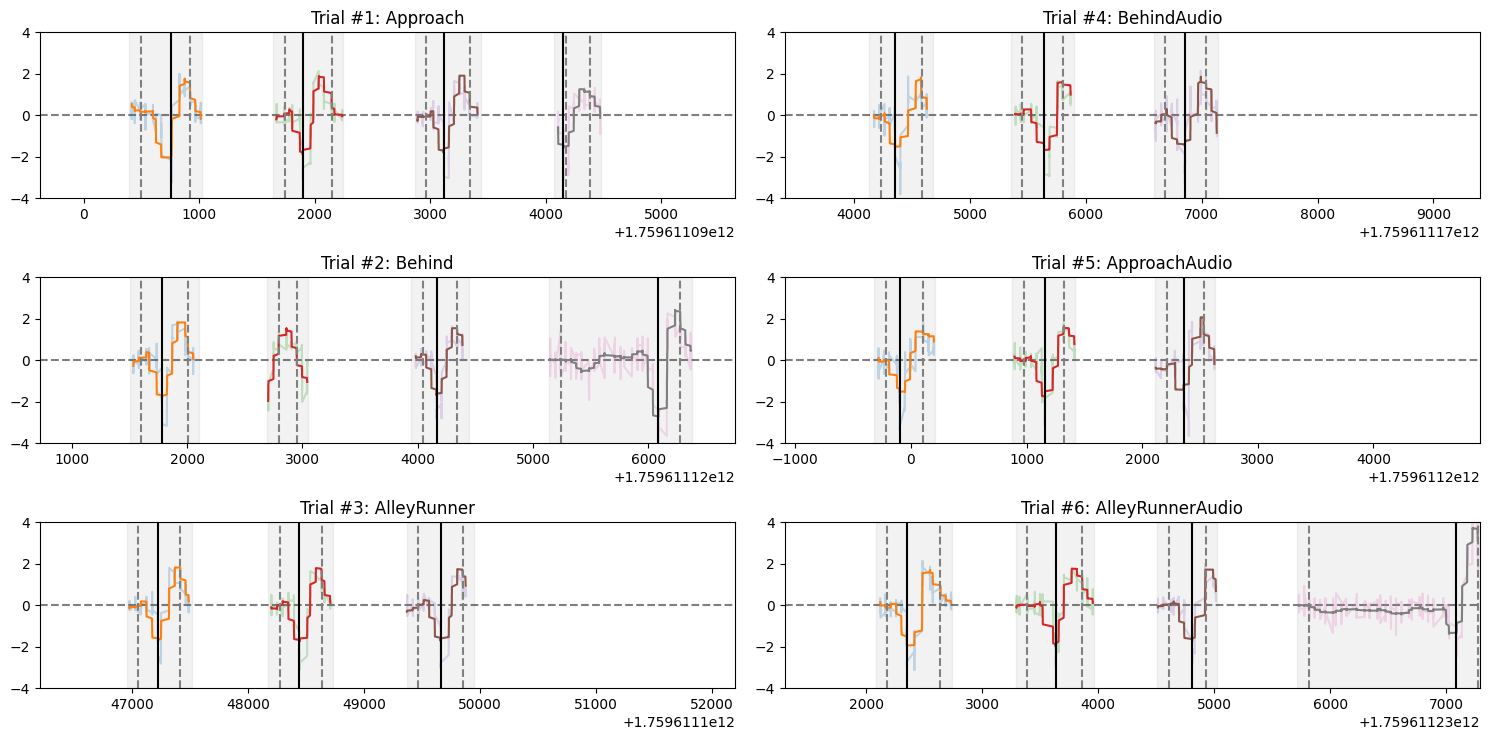

#### Participant P5

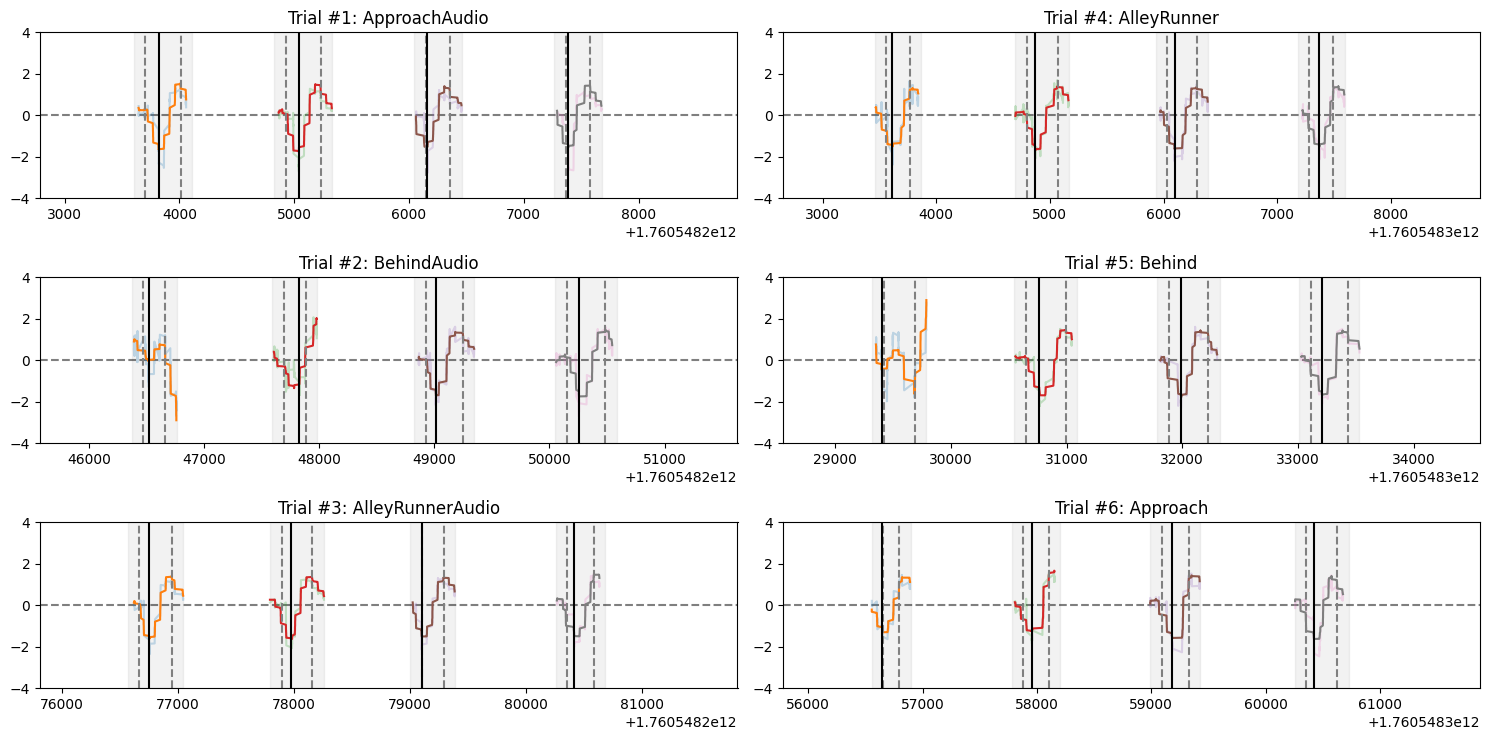

#### Participant P6

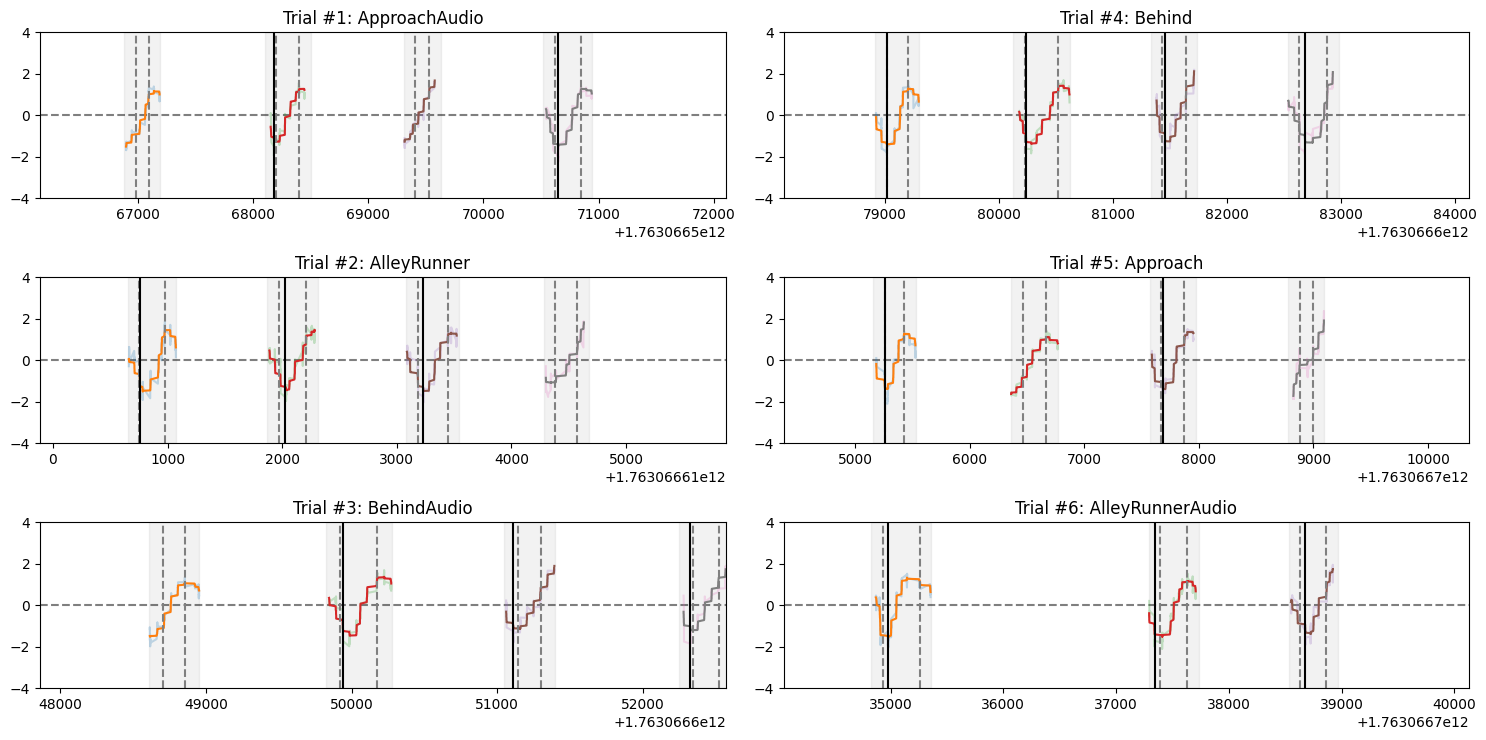

#### Participant P7

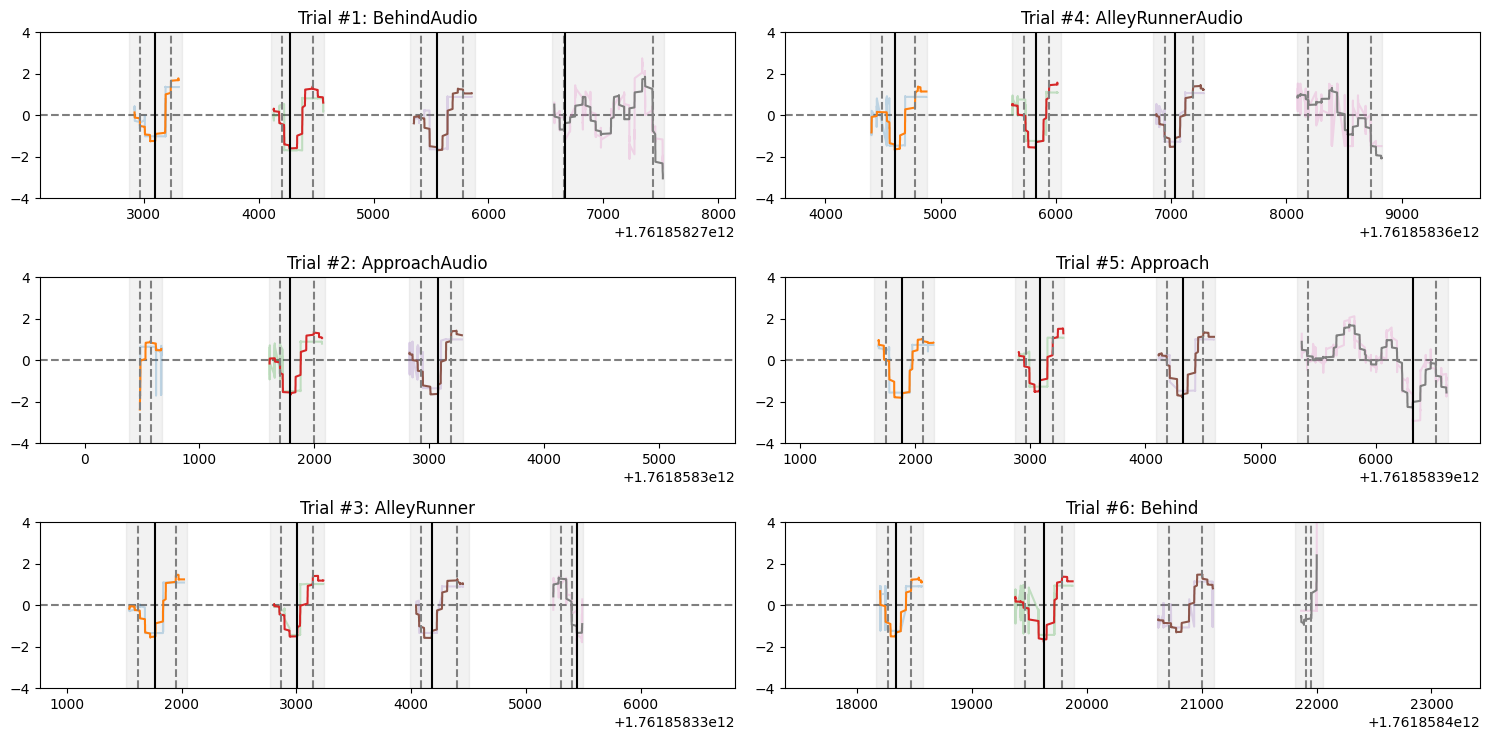

#### Participant P9

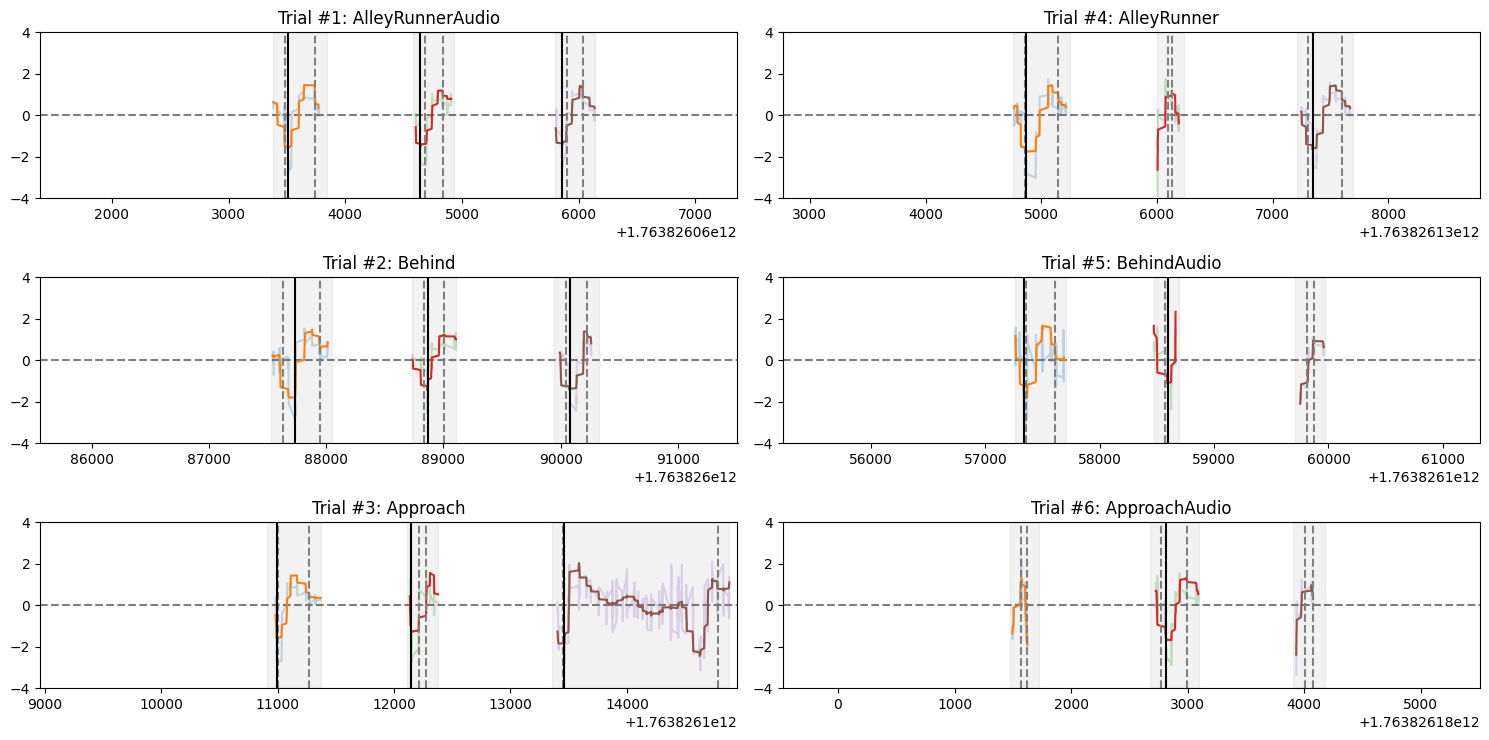

In [12]:
from IPython.display import display, Markdown
import os
from components import file_handling

importlib.reload(blink_handling)
importlib.reload(file_handling)

_DATA_DIR = './data2'
_ACTIVE_PARTICIPANTS = [
    'P1',
    'PI2',
    'P3',
    'P4_Muse2',
    'P5',
    'P6',
    'P7',
    'P9'
]

# Create the output directory for all figures
figure_outdir = os.path.join('.','docs','3.eeg_blink_signals/')
file_handling.mkdirs(figure_outdir)

for p in _ACTIVE_PARTICIPANTS:

    # Get the first estimated blinks, then save it
    pdir = os.path.join(_DATA_DIR, f"{p}")
    tp9_first_blinks, tp10_first_blinks, _, _, _, _ = blink_handling.detect_eeg_blinks(_DATA_DIR, p, window_length=50, polyorder=4)
    tp9_first_blinks.to_csv(os.path.join(pdir, "tp9_blinks.csv"), index=False)
    tp10_first_blinks.to_csv(os.path.join(pdir, "tp10_blinks.csv"), index=False)

    # Now generate the figure
    # Plot the figure. Since we're looking at all 6 trials, let's make a 3-row, 2-col figure
    fig, axes = plt.subplots(3,2,figsize=(15,7.5))

    # Read the trial data
    tdf = pd.read_csv(os.path.join(pdir, "trials.csv"))

    # Iterate through trials
    for _, row in tdf.iterrows():
        # Read the eye data for each trial
        trial_id = row['trial_id']
        tdir = os.path.join(pdir, f"{trial_id}/calibration/")

        # Read the necessary datasets
        eeg_raw = pd.read_csv(os.path.join(tdir, 'eeg_raw.csv'))
        brdf = pd.read_csv(os.path.join(tdir, 'blink_ranges.csv'))

        # Restrict the EEG data
        start_ms = eeg_raw['unix_ms'].iloc[0] + 5000
        end_ms = eeg_raw['unix_ms'].iloc[-1] - 500
        eeg = eeg_raw[eeg_raw['unix_ms'].between(start_ms, end_ms)]

        # Get the subplot indices
        row_index = math.floor((trial_id-1) % 3)
        col_index = math.floor((trial_id-1)/ 3)

        # Plot eye data
        ax = axes[row_index][col_index]
        ax.set_title(f"Trial #{trial_id}: {row['trial_name']}")
        ax.set_xlim(start_ms, end_ms)
        ax.set_ylim(-4, 4)
        ax.axhline(y=0, c='black', linestyle='--', alpha=0.5)

        # Plot blink ranges
        for _, row in brdf.iterrows():
            # Get necessary timestamps
            overlap_counter = row['overlap_counter']
            overlap_ms = row['overlap_unix_ms']
            blink_ms = row['blink_unix_ms']
            range_start_ms = row['start_unix_ms']
            range_end_ms = row['end_unix_ms']
            _eeg = eeg[eeg['unix_ms'].between(range_start_ms, range_end_ms)]

            # Get the relevant x and y data
            x = _eeg['unix_ms'].to_list()
            y = _eeg['TP9'].to_list()
            ys = savgol_filter(y, window_length=75, polyorder=3, mode='nearest')
            z_scores = zscore(ys)

            # Plot things
            ax.plot(x, zscore(y), alpha=0.25)
            ax.plot(x, z_scores)
            ax.axvline(x=overlap_ms, c='gray', linestyle='--')
            ax.axvline(x=blink_ms, c='gray', linestyle='--')
            ax.axvspan(xmin=range_start_ms, xmax=range_end_ms, color='gray', alpha=0.1)

            # This time, we pull from `first_blinks`
            estimations = tp9_first_blinks[(tp9_first_blinks['trial_id']==trial_id) & (tp9_first_blinks['overlap_counter']==overlap_counter)]
            for _, estimate in estimations.iterrows():
                # Draw a vertical line to indicate the estimated blink
                ax.axvline(x=estimate['x'], c='black')

    # Adjust the formatting/layout, and then save it before showing
    plt.tight_layout()
    plt.savefig(os.path.join(figure_outdir, f"{p}.png"), bbox_inches="tight")

    # Show
    display(Markdown(f'#### Participant {p}'))
    plt.show()

## What's Next?

|Previous Notebook|Current Notebook|Next Notebook|
|:-:|:-:|:-:|
|[2.vr_blink_signals.ipynb](./2.vr_blink_signals.ipynb)|<i>3.eeg_blink_signals.ipynb</i>|[4.offset_calculation.ipynb](./4.offset_calculation.ipynb)|

The next notebook, [4.offset_calculation.ipynb](./4.offset_calculation.ipynb), covers how to align the VR and EEG streams using 1) `src/data2/vr_blinks.csv`, 2) `src/data2/tp9_blinks.csv`, and 3) `src/data3/tp10_blinks.csv`